In [3]:
# ## 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from collections import namedtuple
import time
from tqdm.auto import tqdm # Import tqdm for progress bars

def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {'range': {ple_gui.scan_axis: in_range}}
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    #ple_gui._accumulated_data.mean(axis=0)
    #print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    #ple_gui.fit_result[1].params["center"].value
    return ple_gui.fit_result[1]

def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

In [4]:
vector_magnet

<qudi.hardware.vector_magnet.ami_vector_magnet.Magnet3D(0x1f24c0495e0) at 0x000001F26CA5D040>

In [ ]:
vector_magnet.get_field()

In [4]:
vector_magnet.ramp(field_target= [0.1, 0, 0])

Generated 84 points in the first octant.
Generating 3D plot...


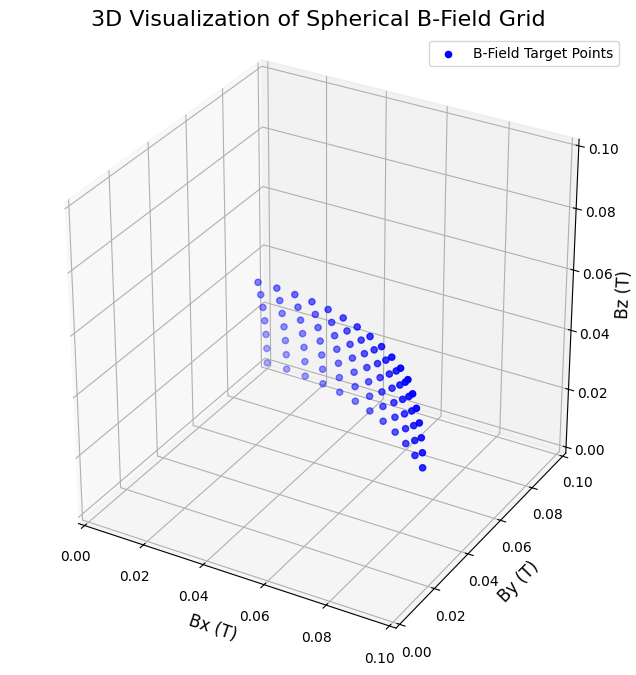

Plot displayed.


In [7]:
B_amplitude = 0.1  # Tesla

# Define the angular resolution of the sweep
theta_steps = 7  # Number of steps from 0 to 90 deg
phi_steps = 12  # Number of steps from 0 to 90 deg

# Create the grid of angles for the first octant (all components positive)
# theta: 0 to pi/2
# phi: 0 to p
thetas = np.linspace(np.pi/2, np.pi/2 - np.pi/10, theta_steps)
phis = np.linspace(0, np.pi/4, phi_steps)

all_field_targets = []

# Iterate through each point on the spherical grid
for phi in phis:
    for theta in thetas:
        # a. Convert spherical to Cartesian coordinates
        By = B_amplitude * np.sin(theta) * np.cos(phi)
        Bx = B_amplitude * np.sin(theta) * np.sin(phi)
        Bz = B_amplitude * np.cos(theta)
        field_target = [Bx, By, Bz]
        all_field_targets.append(field_target)

print(f"Generated {len(all_field_targets)} points in the first octant.")

# ## 3. Prepare Data for Plotting
# Convert the list of points into a NumPy array for easier slicing
points_array = np.array(all_field_targets)

points_array = np.array(all_field_targets)

# Extract X, Y, and Z coordinates
x_coords = points_array[:, 0]
y_coords = points_array[:, 1]
z_coords = points_array[:, 2]

# ## 4. Create the 3D Plot
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o', label='B-Field Target Points')

# Add labels and a title for clarity
ax.set_xlabel('Bx (T)', fontsize=12)
ax.set_ylabel('By (T)', fontsize=12)
ax.set_zlabel('Bz (T)', fontsize=12)
ax.set_title('3D Visualization of Spherical B-Field Grid', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([0, B_amplitude])
ax.set_ylim([0, B_amplitude])
ax.set_zlim([0, B_amplitude])
ax.set_aspect('equal') # This is crucial for a correct aspect ratio

# Add a legend
ax.legend()

# Show the plot
plt.show()
print("Plot displayed.")

Generating 3D plot...


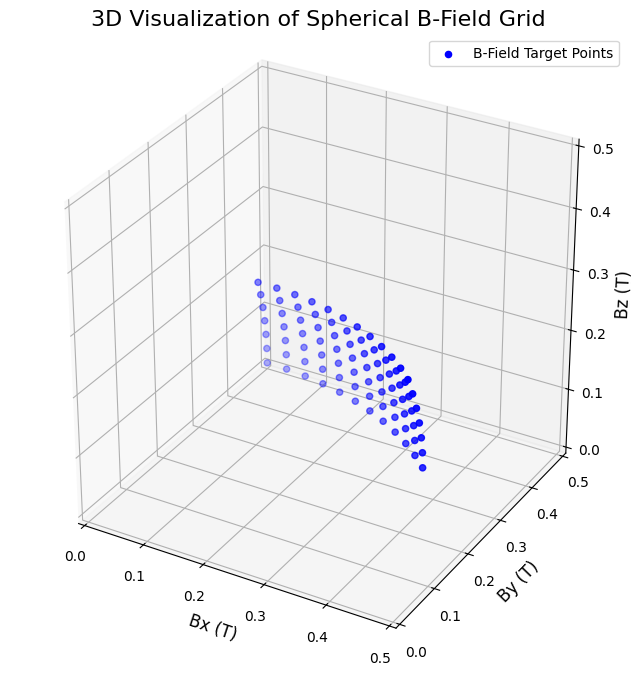

Plot displayed.


Generating 3D plot of planar sweeps...


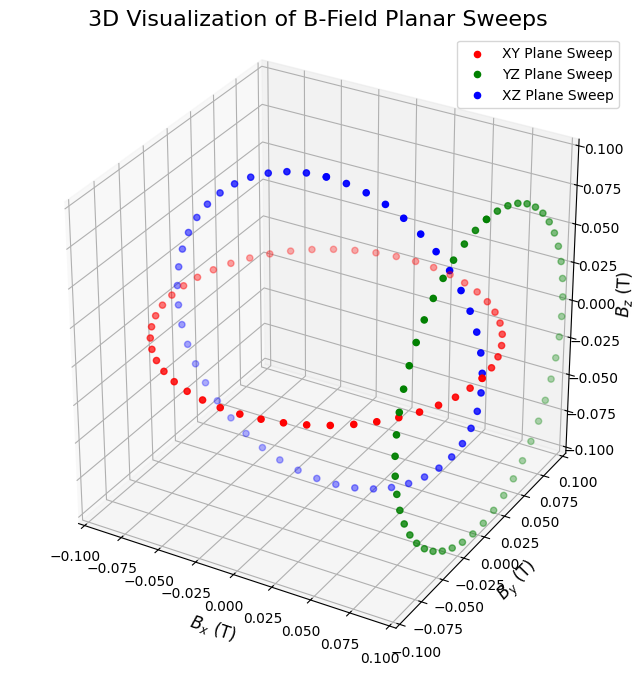

Plot displayed.


In [9]:
# ## 1. Define Simulation Parameters
# Define the magnetic field amplitude
B_amplitude = 0.1  # Tesla

# Define the angular resolution for the sweep in each plane
num_steps = 50  # Number of points for each 90-degree arc

# ## 2. Generate B-Field Target Points for Each Plane
# Create a single angle array for a 90-degree sweep (0 to pi/2)
angles = np.linspace(0, 2*np.pi, num_steps)

# --- XY Plane Sweep (Bz = 0) ---
# Bx and By trace a circular path in the XY plane.
Bx_xy = B_amplitude * np.cos(angles)
By_xy = B_amplitude * np.sin(angles)
Bz_xy = np.zeros(num_steps)

# --- YZ Plane Sweep (Bx = 0) ---
# By and Bz trace a circular path in the YZ plane.
Bx_yz = np.zeros(num_steps) + B_amplitude
By_yz = B_amplitude * np.sin(angles)
Bz_yz = B_amplitude * np.cos(angles)

# --- XZ Plane Sweep (By = 0) ---
# Bx and Bz trace a circular path in the XZ plane.
Bx_xz = B_amplitude * np.sin(angles)
By_xz = np.zeros(num_steps)
Bz_xz = B_amplitude * np.cos(angles)

# ## 3. Create the 3D Plot
print("Generating 3D plot of planar sweeps...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plots for each plane
ax.scatter(Bx_xy, By_xy, Bz_xy, c='r', marker='o', label='XY Plane Sweep')
ax.scatter(Bx_yz, By_yz, Bz_yz, c='g', marker='o', label='YZ Plane Sweep')
ax.scatter(Bx_xz, By_xz, Bz_xz, c='b', marker='o', label='XZ Plane Sweep')

# Add labels and a title for clarity
ax.set_xlabel('$B_x$ (T)', fontsize=12)
ax.set_ylabel('$B_y$ (T)', fontsize=12)
ax.set_zlabel('$B_z$ (T)', fontsize=12)
ax.set_title('3D Visualization of B-Field Planar Sweeps', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([-B_amplitude, B_amplitude])
ax.set_ylim([-B_amplitude, B_amplitude])
ax.set_zlim([-B_amplitude, B_amplitude])
ax.set_aspect('equal')  # Crucial for a correct aspect ratio

# Add a legend to identify the sweeps
ax.legend()
ax.grid(True)

# Show the plot
plt.show()
print("Plot displayed.")

In [27]:
vector_magnet.ramp(field_target= [0.0,0.02,0.07])

In [31]:
ple_gui._fit_averaged = False

Created folder: Z:\Vlad\heavyIV\202-2-ARed\CPW\mk-II\B_sweep_XY_perp


In [19]:
all_field_targets

[[0.0, 0.5, 3.061616997868383e-17], [0.0, 0.4993147673772869, 0.026167978121471983], [0.0, 0.49726094768413664, 0.05226423163382673], [0.0, 0.4938441702975689, 0.07821723252011546], [0.0, 0.4890738003669028, 0.10395584540887973], [0.0, 0.48296291314453416, 0.12940952255126037], [0.0, 0.47552825814757677, 0.15450849718747373], [0.03566959159961617, 0.49872605730512676, 3.061616997868383e-17], [0.03562070766401035, 0.4980425705766017, 0.026167978121471983], [0.03547418984466251, 0.49599398378064075, 0.05226423163382673], [0.03523043973673116, 0.49258591195125623, 0.07821723252011546], [0.034890125442319266, 0.4878276963764402, 0.10395584540887973], [0.03445417973925286, 0.4817323789943438, 0.12940952255126037], [0.033923797524401826, 0.47431666664623096, 0.15450849718747373], [0.07115741913664257, 0.49491072094046634, 3.061616997868383e-17], [0.07105990036676157, 0.49423246299782864, 0.026167978121471983], [0.07076761134928841, 0.49219954822779116, 0.05226423163382673], [0.07028135322810

In [ ]:
folder = r'Z:\Vlad\heavyIV\202-2-ARed\CPW\mk-V\B_sweep_YZ_X_1000'
if os.path.exists(folder):
    raise FileExistsError(f"The folder '{folder}' already exists. Please rename the folder.")
else:
    os.makedirs(folder)
    print(f"Created folder: {folder}")
print("Waiting for initial vector magnet ramping to complete...")
while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
    print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
    time.sleep(30)
print("✅ Vector magnet is ready.")

ple_splitting = []

# --- Main Loop with tqdm Progress Bar ---
# Use tqdm to create a progress bar for the loop over field targets
for field_target in tqdm(zip(Bx_xy, By_xy, Bz_xy), desc="Field Target Progress"):
    print(f"\n--- Starting new measurement for target: {field_target} ---")
    
    # --- Ramping the Field ---
    print(f"Ramping to field target: {field_target} T")
    vector_magnet.ramp(field_target=field_target)
    
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        
        time.sleep(2)
    
    
    # --- Performing PLE Scan ---
    
    fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
    

    # --- Waiting for Laser Scanner ---
    while laser_scanner_logic.module_state() == 'locked':
        
        time.sleep(0.5)
    

    # --- Calculating Splitting ---
    delta = fit.params['center_2'].value - fit.params['center_1'].value
    
    ple_splitting.append(delta)

    # --- Saving Data ---
    tag = f"target_{field_target}_T"
    
    save_ple(tag=tag,
             poi_name=None,
             folder_name=folder)
    

print("\n--- All measurements complete! ---")
print(f"Final PLE Splitting Values (MHz): {ple_splitting}")

Waiting for initial vector magnet ramping to complete...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: 

Field Target Progress:   0%|          | 0/84 [00:00<?, ?it/s]


--- Starting new measurement for target: [0.0, 0.5, 3.061616997868383e-17] ---
Ramping to field target: [0.0, 0.5, 3.061616997868383e-17] T

--- Starting new measurement for target: [0.0, 0.4993147673772869, 0.026167978121471983] ---
Ramping to field target: [0.0, 0.4993147673772869, 0.026167978121471983] T

--- Starting new measurement for target: [0.0, 0.49726094768413664, 0.05226423163382673] ---
Ramping to field target: [0.0, 0.49726094768413664, 0.05226423163382673] T

--- Starting new measurement for target: [0.0, 0.4938441702975689, 0.07821723252011546] ---
Ramping to field target: [0.0, 0.4938441702975689, 0.07821723252011546] T

--- Starting new measurement for target: [0.0, 0.4890738003669028, 0.10395584540887973] ---
Ramping to field target: [0.0, 0.4890738003669028, 0.10395584540887973] T

--- Starting new measurement for target: [0.0, 0.48296291314453416, 0.12940952255126037] ---
Ramping to field target: [0.0, 0.48296291314453416, 0.12940952255126037] T

--- Starting new 

: 

In [36]:
field_target

[0.3362492559819787, 0.3362492559819787, 0.15450849718747373]

In [32]:
import os
import time
import numpy as np
from tqdm import tqdm

# --- Assume these hardware control objects and functions are defined elsewhere ---
# from your_instrument_library import vector_magnet, laser_scanner_logic
# from your_analysis_library import do_ple_scan, save_ple

# ==============================================================================
# ## 1. Configuration
# ==============================================================================
# Define the base directory for saving all measurement data
BASE_FOLDER = r'Z:\Vlad\heavyIV\202-2-ARed\CPW\mk-VI'
B_AMPLITUDE = 0.1  # Tesla
NUM_STEPS = 50     # Number of points per 90-degree arc
Bx_offset = 0
# ==============================================================================
# ## 2. Generate B-Field Target Points for Each Plane
# ==============================================================================
print("Generating B-field target points for all planes...")
angles = np.linspace(0, 2*np.pi, NUM_STEPS)

# --- Define the points and folder names for each sweep ---
sweep_definitions = {
    'XY_perp': {
        'points': list(zip(
            B_AMPLITUDE * np.cos(angles),      # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            np.zeros(NUM_STEPS)                # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XY_perp')
    },
    'YZ_perp': {
        'points': list(zip(
            np.zeros(NUM_STEPS) + Bx_offset,               # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_YZ_perp')
    },
    'XZ_perp': {
        'points': list(zip(
            B_AMPLITUDE * np.sin(angles),      # Bx
            np.zeros(NUM_STEPS),               # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XZ_perp')
    }
}

# ==============================================================================
# ## 3. Main Measurement Function
# ==============================================================================
def run_planar_sweep(plane_name: str, field_targets: list, output_folder: str):
    """
    Executes a full B-field sweep measurement for a given set of points.
    
    Args:
        plane_name (str): Name of the plane being swept (e.g., 'XY_perp').
        field_targets (list): A list of [Bx, By, Bz] target tuples.
        output_folder (str): The full path to the folder where data will be saved.
    """
    print(f"\n--- 🚀 Starting Measurement for Plane: {plane_name} ---")
    
    # --- Create and verify destination folder ---
    if os.path.exists(output_folder):
        raise FileExistsError(f"The folder '{output_folder}' already exists. Please rename or delete it.")
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

    ple_splitting = []
    field_targets = np.array(field_targets)
    # --- Main Loop with Progress Bar ---
    for field_target in tqdm(field_targets, desc=f"{plane_name} Sweep Progress"):
        print(f"\n--- Ramping to target: ({field_target[0]:.2f}, {field_target[1]:.2f}, {field_target[2]:.2f}) T ---")
        
        # 1. Ramp the field
        vector_magnet.ramp(field_target=field_target)
        while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
            time.sleep(2)
        print("Ramping complete.")

        # 2. Perform PLE Scan
        print("Performing PLE scan...")
        fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
        
        # 3. Wait for Laser Scanner to be ready
        while laser_scanner_logic.module_state() == 'locked':
            time.sleep(0.5)
        print("PLE scan complete.")

        # 4. Calculate Splitting
        delta = fit.params['center_2'].value - fit.params['center_1'].value
        ple_splitting.append(delta)
        print(f"Calculated splitting: {delta:.2f} MHz")

        # 5. Save Data
        tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        
    print(f"\n✅ --- {plane_name} Measurement Complete! ---")
    return ple_splitting


Generating B-field target points for all planes...


Generating 3D plot...


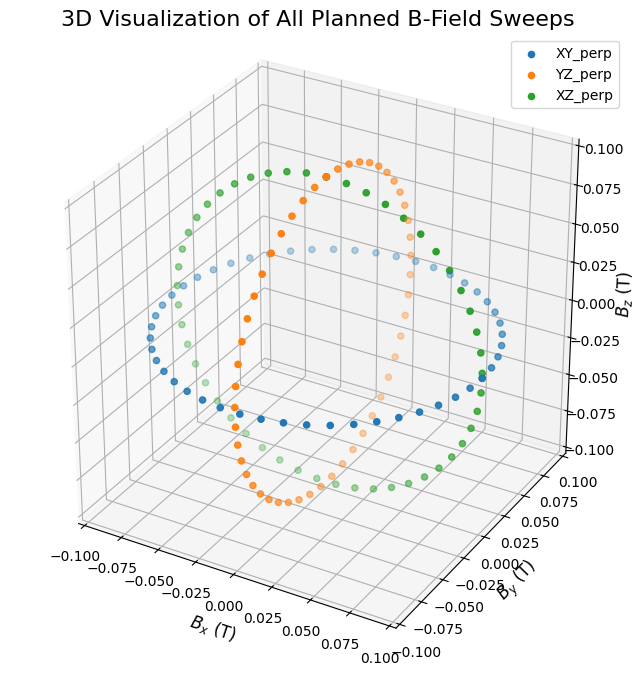

Plot displayed.


In [33]:
# ==============================================================================
# ## 3. Create the 3D Plot for Verification
# ==============================================================================
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points for each plane
for plane_name, config in sweep_definitions.items():
    # Unzip the list of (x, y, z) tuples into three separate lists

    points = config['points']
    if not points: continue # Skip if no points
    x_coords, y_coords, z_coords = zip(*points)
    
    # Create the scatter plot for the current plane
    ax.scatter(x_coords, y_coords, z_coords,  marker='o', label=plane_name)

# --- Add labels and titles for clarity ---
ax.set_xlabel('$B_x$ (T)', fontsize=12)
ax.set_ylabel('$B_y$ (T)', fontsize=12)
ax.set_zlabel('$B_z$ (T)', fontsize=12)
ax.set_title('3D Visualization of All Planned B-Field Sweeps', fontsize=16)

# --- Set axis limits and aspect ratio ---
ax.set_xlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_ylim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_zlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_aspect('equal')  # Crucial for correct spherical appearance

# --- Add legend and grid ---
ax.legend()
ax.grid(True)

# --- Show the plot ---
plt.show()
print("Plot displayed.")

In [34]:
config['points']

[(0.0, 0.0, 0.1), (0.0127877161684506, 0.0, 0.09917900138232462), (0.025365458390950738, 0.0, 0.09672948630390295), (0.03752670048793741, 0.0, 0.09269167573460219), (0.049071755200393787, 0.0, 0.08713187041233894), (0.05981105304912159, 0.0, 0.08014136218679568), (0.06956825506034864, 0.0, 0.07183493500977277), (0.07818314824680299, 0.0, 0.062348980185873364), (0.08551427630053461, 0.0, 0.05183925683105252), (0.09144126230158124, 0.0, 0.040478334312239406), (0.09586678530366606, 0.0, 0.02845275866310327), (0.09871817834144501, 0.0, 0.01595998950333793), (0.09994862162006879, 0.0, 0.0032051577571655335), (0.09953791129491983, 0.0, -0.009602302590768155), (0.09749279121818237, 0.0, -0.022252093395631434), (0.09384684220497605, 0.0, -0.03453650544213075), (0.08865993063730002, 0.0, -0.04625382902408351), (0.0820172254596956, 0.0, -0.057211666012216944), (0.07402779970753158, 0.0, -0.06723008902613166), (0.06482283953077887, 0.0, -0.07614459583691342), (0.054553490121054905, 0.0, -0.083808

In [35]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: XY_perp ---
Created folder: Z:\Vlad\heavyIV\202-2-ARed\CPW\mk-VI\B_sweep_XY_perp


XY_perp Sweep Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Ramping to target: (0.10, 0.00, 0.00) T ---
Ramping complete.
Performing PLE scan...


XY_perp Sweep Progress:   2%|▏         | 1/50 [02:17<1:52:13, 137.43s/it]

PLE scan complete.
Calculated splitting: -10.80 MHz

--- Ramping to target: (0.10, 0.01, 0.00) T ---
Ramping complete.
Performing PLE scan...


...

PLE scan complete.
Calculated splitting: 193.03 MHz

--- Ramping to target: (-0.01, 0.00, 0.10) T ---
Ramping complete.
Performing PLE scan...


XZ_perp Sweep Progress:  98%|█████████▊| 49/50 [40:19<00:50, 50.26s/it]

PLE scan complete.
Calculated splitting: -197.92 MHz

--- Ramping to target: (-0.00, 0.00, 0.10) T ---
Ramping complete.
Performing PLE scan...


XZ_perp Sweep Progress: 100%|██████████| 50/50 [41:11<00:00, 49.43s/it]

PLE scan complete.
Calculated splitting: 194.40 MHz

✅ --- XZ_perp Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for XY_perp Plane:

Results for YZ_perp Plane:

Results for XZ_perp Plane:

--- Script finished. ---


In [36]:


def get_symmetry_vectors(angle_xy: float, angle_xz: float, angle_yz: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Determines the 3D direction vector of a symmetry axis and a perpendicular vector.

    The calculation is based on the angles of the vector's projections onto the
    XY, XZ, and YZ planes.

    Args:
        angle_xy (float): The angle in degrees of the vector's projection
                          in the XY plane, measured from the X-axis.
        angle_xz (float): The angle in degrees of the vector's projection
                          in the XZ plane, measured from the X-axis.
        angle_yz (float): The angle in degrees of the vector's projection
                          in the YZ plane, measured from the Y-axis.

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing two NumPy arrays:
            - vector_aligned: A 3D unit vector (x, y, z) aligned with the
                              symmetry axis.
            - vector_perpendicular: A 3D unit vector perpendicular to the
                                      symmetry axis.
    """
    # Small tolerance for floating point comparisons
    TOL = 1e-9

    # --- 1. Calculate the vector aligned with the symmetry axis ---
    
    # Check for the special case where the vector lies in the YZ plane (x=0)
    # This occurs when the projection on the XZ plane is aligned with the Z-axis.
    if abs((angle_xz % 180) - 90) < TOL:
        # If x=0, the vector is (0, y, z)
        vx = 0.0
        # The orientation in the YZ plane is given by angle_yz
        rad_yz = np.deg2rad(angle_yz)
        vy = np.cos(rad_yz)
        vz = np.sin(rad_yz)
        vector_aligned = np.array([vx, vy, vz])

    else:
        # General case: convert projection angles to spherical coordinates (theta, phi)
        # The angle in the XY plane is the azimuthal angle, phi.
        phi = np.deg2rad(angle_xy)

        # The angle in the XZ plane relates to the polar angle, theta.
        # tan(angle_xz) = vz / vx = cos(theta) / (sin(theta)*cos(phi)) = cot(theta) / cos(phi)
        # From this, we find cot(theta)
        rad_xz = np.deg2rad(angle_xz)
        cot_theta = np.tan(rad_xz) * np.cos(phi)

        # Find sin(theta) and cos(theta) from cot(theta)
        # Using 1 + cot^2(theta) = csc^2(theta) = 1/sin^2(theta)
        sin_theta = 1.0 / np.sqrt(1 + cot_theta**2)
        cos_theta = cot_theta * sin_theta
        
        # Convert spherical coordinates to Cartesian coordinates (x,y,z)
        vx = sin_theta * np.cos(phi)
        vy = sin_theta * np.sin(phi)
        vz = cos_theta
        vector_aligned = np.array([vx, vy, vz])

    # --- 2. Calculate a vector perpendicular to the aligned vector ---
    
    # We find a perpendicular vector by taking the cross product of the aligned
    # vector with a non-parallel basis vector (e.g., X or Y axis).

    # If the aligned vector is not parallel to the X-axis, cross with (1,0,0)
    if abs(vector_aligned[0]) < 0.9:
        temp_vec = np.array([1.0, 0.0, 0.0])
    # Otherwise, it's nearly parallel to the X-axis, so cross with (0,1,0)
    else:
        temp_vec = np.array([0.0, 1.0, 0.0])

    # The cross product is perpendicular to both original vectors
    vector_perpendicular = np.cross(vector_aligned, temp_vec)

    # Normalize the result to get a unit vector
    vector_perpendicular /= np.linalg.norm(vector_perpendicular)

    return vector_aligned, vector_perpendicular

In [ ]:
# Example: Angles from a hypothetical measurement
xy_proj_angle = 45.0  # degrees
xz_proj_angle = 45.0  # degrees
yz_proj_angle = 35.26 # degrees, calculated for consistency with the other two

# Get the aligned and perpendicular vectors
aligned_vec, perp_vec = get_symmetry_vectors(xy_proj_angle, xz_proj_angle, yz_proj_angle)

# Let's print the results, rounded for clarity
print(f"Symmetry Axis (Aligned Vector): {np.round(aligned_vec, 3)}")
print(f"A Perpendicular Vector:         {np.round(perp_vec, 3)}")

# You can verify that they are perpendicular by checking their dot product (should be ~0)
dot_product = np.dot(aligned_vec, perp_vec)
print(f"\nDot product of the two vectors: {dot_product:.10f}")